# Read Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/train_test.csv")
df


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [4]:
df.isnull().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,300


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [7]:
df.describe(include="O").T

,count,unique,top,freq
load_id,48000,48000,TR-047961,1
pickup,48000,64,Oklahoma City,1242
delivery,48000,64,Lexington,1197
equipment,48000,3,Dry Van,27202
date,48000,304,2025-06-17,198


# Data Quality Analysis

In [8]:
print("Negative weights:", (df["weight"] < 0).sum())
print("Zero weights:", (df["weight"] == 0).sum())
print(20*"*")
print("Missing weights:", df["weight"].isna().sum())
print("Missing market index:", df["market_index"].isna().sum())
print(20*"*")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate load IDs:", df["load_id"].duplicated().sum())
print(20*"*")
print("Weight skewness:", df["weight"].skew())
print("Posted rate skewness:", df["posted_rate"].skew())

Negative weights: 292
Zero weights: 0
********************
Missing weights: 300
Missing market index: 374
********************
Duplicate rows: 0
Duplicate load IDs: 0
********************
Weight skewness: -1.9103914374430284
Posted rate skewness: 1.9023948792201815


# Clean invalid values in "Weight" Column

In [9]:
df.loc[df["weight"] < 0, ["weight",  "distance",  "posted_rate"]].describe()

,weight,distance,posted_rate
count,292.000000,292.000000,292.000000
mean,-31724.195205,1120.920205,2389.786233
std,8262.536326,733.132047,1641.761285
min,-47500.000000,75.100000,247.370000
25%,-37284.250000,531.975000,1257.410000
50%,-31821.500000,930.450000,1994.960000
75%,-25928.500000,1537.125000,3185.257500
max,-5000.000000,3161.700000,14561.210000


In [10]:
df.loc[df["weight"] < 0, ["weight", "equipment", "date"]].head(20)

,weight,equipment,date
68,-36559.0,Reefer,2025-01-01
204,-26670.0,Dry Van,2025-01-02
206,-20003.0,Reefer,2025-01-02
225,-23981.0,Reefer,2025-01-02
376,-41397.0,Dry Van,2025-01-03
446,-37215.0,Reefer,2025-01-03
495,-31214.0,Dry Van,2025-01-04
641,-41023.0,Dry Van,2025-01-05
806,-28320.0,Dry Van,2025-01-06
1093,-25153.0,Dry Van,2025-01-07


In [11]:
# it just a try to ensure that if the negative weights is sign error or not
df.loc[df["weight"] < 0, "weight"].abs().describe()

,weight
count,292.000000
mean,31724.195205
std,8262.536326
min,5000.000000
25%,25928.500000
50%,31821.500000
75%,37284.250000
max,47500.000000


In [12]:
df.loc[df["weight"] > 0, "weight"].describe()

,weight
count,47408.000000
mean,31415.358674
std,7994.902979
min,5000.000000
25%,25922.000000
50%,31493.500000
75%,37063.000000
max,47500.000000


In [13]:
negative_abs = df.loc[df["weight"] < 0, "weight"].abs()

positive = df.loc[df["weight"] > 0, "weight"]

negative_abs.isin(positive).sum()

np.int64(232)

In [14]:

df.loc[df["weight"] < 0, "equipment"].value_counts()

,count
equipment,
Dry Van,155
Flatbed,70
Reefer,67


In [15]:
# convert negative weights to positive
negative_mask = df["weight"] < 0
df.loc[negative_mask, "weight"] = df.loc[negative_mask, "weight"].abs()

In [16]:
df["weight"].describe()

,weight
count,47700.000000
mean,31417.249245
std,7996.515399
min,5000.000000
25%,25922.000000
50%,31496.000000
75%,37063.250000
max,47500.000000


In [17]:
print("Negative weights:", (df["weight"] < 0).sum())
print("Zero weights:", (df["weight"] == 0).sum())
print("Missing weights:", df["weight"].isna().sum())

Negative weights: 0
Zero weights: 0
Missing weights: 300


# Handle Missing Values in Weight Column

In [18]:
# display the Rows which have NaN in both n columns which have missing (weight & market index)
df[df["weight"].isna() & df["market_index"].isna()]

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
28995,TR-028996,Amarillo,Greensboro,33.17137,-104.36789,35.98195,-82.78379,1440.3,Flatbed,NaN,2025-07-02,NaN,2.03283,1156.87


In [19]:
# show if the missing is related with any column by comparing the result with the whole data
df.loc[
    df["weight"].isna(),
    ["pickup", "delivery", "distance", "equipment", "date", "market_index", "quote_signal", "posted_rate"]
].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pickup,300,62,Richmond,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,300,60,Hartford,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance,300.0,NaN,NaN,NaN,1145.482,737.277714,107.0,549.35,944.4,1681.875,3237.4
equipment,300,3,Dry Van,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,300,193,2025-05-07,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market_index,299.0,NaN,NaN,NaN,1.061744,0.169915,0.7427,0.916125,1.03499,1.19626,1.43599
quote_signal,300.0,NaN,NaN,NaN,2.072164,0.279222,1.21667,1.911285,2.071585,2.232742,3.0639
posted_rate,300.0,NaN,NaN,NaN,2350.665767,1390.972806,148.72,1229.66,1984.995,3397.89,6546.69


In [20]:
pd.crosstab(
    df["equipment"],
    df["weight"].isna(),
    normalize="index"
) * 100

weight,False,True
equipment,,
Dry Van,99.356665,0.643335
Flatbed,99.371644,0.628356
Reefer,99.418846,0.581154


In [21]:
# number of missing in each date
df.groupby("date")["weight"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(15)

,weight
date,
2025-09-08,5
2025-05-07,5
2025-02-16,4
2025-01-08,4
2025-01-07,4
2025-07-09,4
2025-01-13,4
2025-02-01,4
2025-02-23,4


In [22]:
# no relationship or pattern  between the missing weights and Equipemnt or Data
# we impute the missing with the median

weight_median = df["weight"].median()
df["weight"] = df["weight"].fillna(weight_median)

In [23]:
weight_median

31496.0

In [24]:
print("Missing weights:", df["weight"].isna().sum())
print("Negative weights:", (df["weight"] < 0).sum())

Missing weights: 0
Negative weights: 0


# Handle Missing Values in market_index

In [25]:
df.loc[
    df["market_index"].isna(),
    ["pickup", "delivery", "distance", "equipment", "weight", "date", "quote_signal", "posted_rate"]
].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pickup,374,62,Shreveport,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,374,63,Fort Wayne,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distance,374.0,NaN,NaN,NaN,1164.747861,751.243031,70.0,553.525,991.45,1626.725,3163.4
equipment,374,3,Dry Van,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,374.0,NaN,NaN,NaN,30397.895722,7979.886785,7483.0,25334.25,30642.0,35950.5,47500.0
date,374,209,2025-06-15,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quote_signal,374.0,NaN,NaN,NaN,2.072137,0.298629,0.9858,1.897158,2.057835,2.22886,3.15398
posted_rate,374.0,NaN,NaN,NaN,2392.115107,1434.640755,207.71,1254.2875,2081.1,3294.79,9454.94


In [26]:
pd.crosstab(
    df["equipment"],
    df["market_index"].isna(),
    normalize="index"
) * 100

market_index,False,True
equipment,,
Dry Van,99.257408,0.742592
Flatbed,99.166000,0.834000
Reefer,99.178082,0.821918


In [27]:
daily_missing_rate = (
    df.groupby("date")["market_index"]
      .apply(lambda x: x.isna().mean() * 100)
      .sort_values(ascending=False)
)

daily_missing_rate.head(15)

,market_index
date,
2025-07-27,3.378378
2025-06-15,2.976190
2025-03-28,2.857143
2025-10-11,2.758621
2025-02-28,2.649007
2025-05-20,2.614379
2025-10-02,2.597403
2025-06-16,2.453988
2025-01-26,2.380952


In [28]:
df.groupby("date")["market_index"].agg(
    ["count", "mean", "median", "std"]
).head(20)

,count,mean,median,std
date,,,,
2025-01-01,144,0.961224,0.962590,0.024493
2025-01-02,166,0.986606,0.989030,0.025281
2025-01-03,156,0.940339,0.941040,0.026063
2025-01-04,154,0.857702,0.855715,0.023678
2025-01-05,152,0.801855,0.800030,0.024737
2025-01-06,167,0.813340,0.813120,0.027817
2025-01-07,160,0.888123,0.888890,0.025898
2025-01-08,188,0.973030,0.971425,0.023872
2025-01-09,146,1.000927,0.998300,0.023554


In [29]:
df.groupby("date")["market_index"].transform("median")

,market_index
0,0.96259
1,0.96259
2,0.96259
3,0.96259
4,0.96259
...,...
47995,0.98880
47996,0.98880
47997,0.98880
47998,0.98880


In [30]:
df["market_index"] = df["market_index"].fillna(
    df.groupby("date")["market_index"].transform("median")
)

In [31]:
df["market_index"].isna().sum()

np.int64(0)

In [32]:
df.shape

(48000, 14)

# Some EDA

In [33]:
cat_cols = df.select_dtypes("O").columns
num_cols = df.select_dtypes("float").columns

print(f"Categorical columns : {cat_cols}")
print(f"Numerical columns : {num_cols}")

Categorical columns : Index(['load_id', 'pickup', 'delivery', 'equipment', 'date'], dtype='object')
Numerical columns : Index(['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance',
       'weight', 'market_index', 'quote_signal', 'posted_rate'],
      dtype='object')


In [34]:
# for categorical columns
for col in ['pickup', 'delivery', 'equipment']:
  print(f"\n===== {col} =====")
  print(f"col : {col}")
  print(f"Unique Values : {df[col].nunique()}")
  print(f"Value Counts : \n{df[col].value_counts()}")


===== pickup =====
col : pickup
Unique Values : 64
Value Counts : 
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
                 ... 
Detroit           337
Washington        337
St. Louis         318
Las Vegas         277
Dallas            276
Name: count, Length: 64, dtype: int64

===== delivery =====
col : delivery
Unique Values : 64
Value Counts : 
delivery
Lexington      1197
Fort Wayne     1176
Baton Rouge    1167
Bakersfield    1156
Hartford       1143
               ... 
St. Louis       344
Birmingham      318
Detroit         307
Dallas          306
Las Vegas       292
Name: count, Length: 64, dtype: int64

===== equipment =====
col : equipment
Unique Values : 3
Value Counts : 
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


<Axes: xlabel='posted_rate', ylabel='Count'>

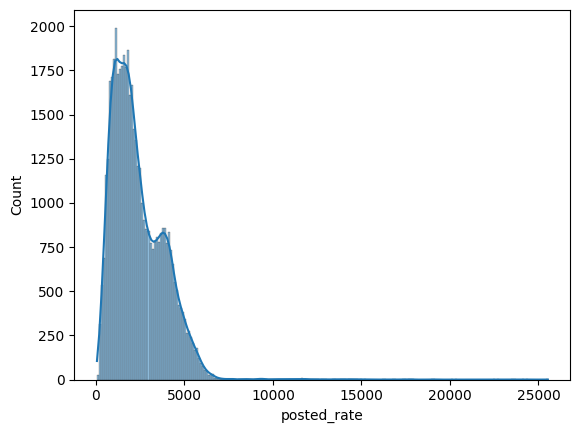

In [35]:
sns.histplot(df["posted_rate"], kde=True)

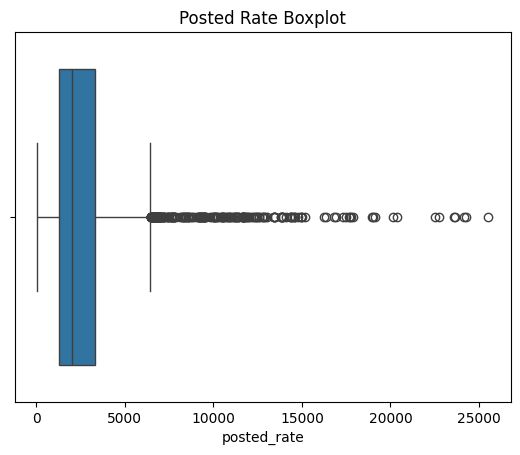

In [36]:
sns.boxplot(x=df["posted_rate"])
plt.title("Posted Rate Boxplot")
plt.show()

In [37]:
df[["distance", "posted_rate"]].corr()

,distance,posted_rate
distance,1.000000,0.908519
posted_rate,0.908519,1.000000


<Axes: xlabel='distance', ylabel='posted_rate'>

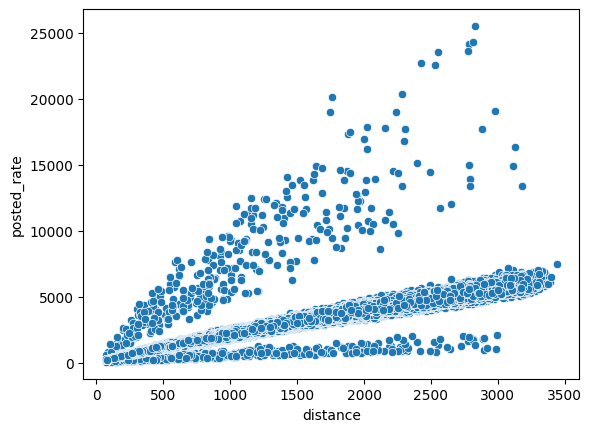

In [38]:
sns.scatterplot(
    data=df,
    x="distance",
    y="posted_rate"
)

<Axes: xlabel='distance', ylabel='posted_rate'>

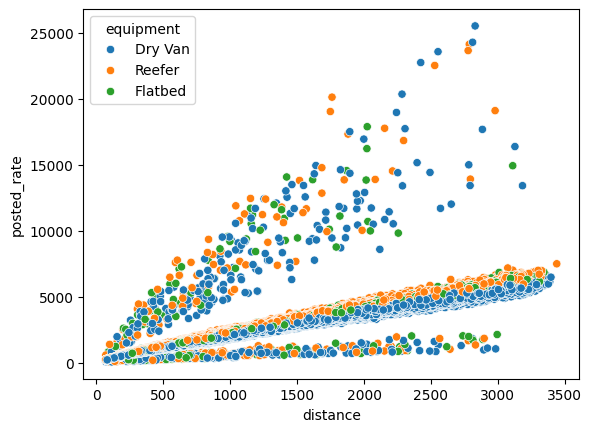

In [39]:
sns.scatterplot(
    data=df,
    x="distance",
    y="posted_rate",
    hue="equipment"
)

<Axes: xlabel='distance', ylabel='posted_rate'>

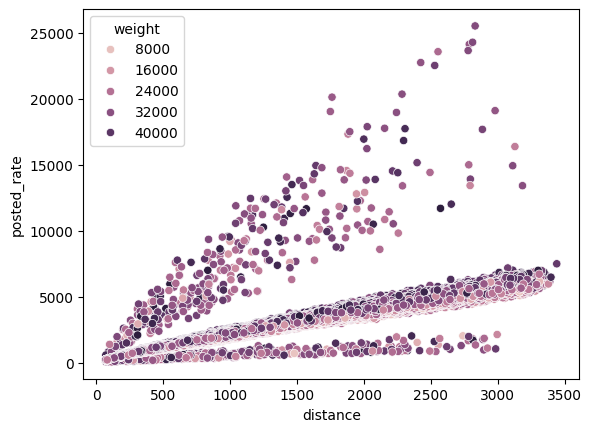

In [40]:
sns.scatterplot(
    data=df,
    x="distance",
    y="posted_rate",
    hue="weight"
)

<Axes: >

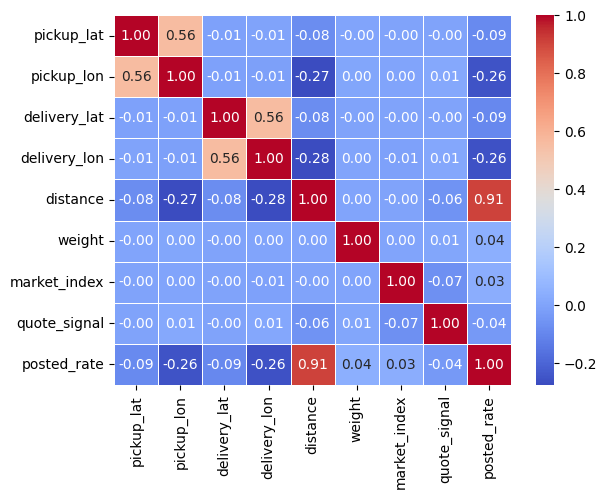

In [41]:
mat = df[num_cols].corr()
sns.heatmap(mat , annot=True,fmt=".2f",linewidths=0.5,cmap="coolwarm")

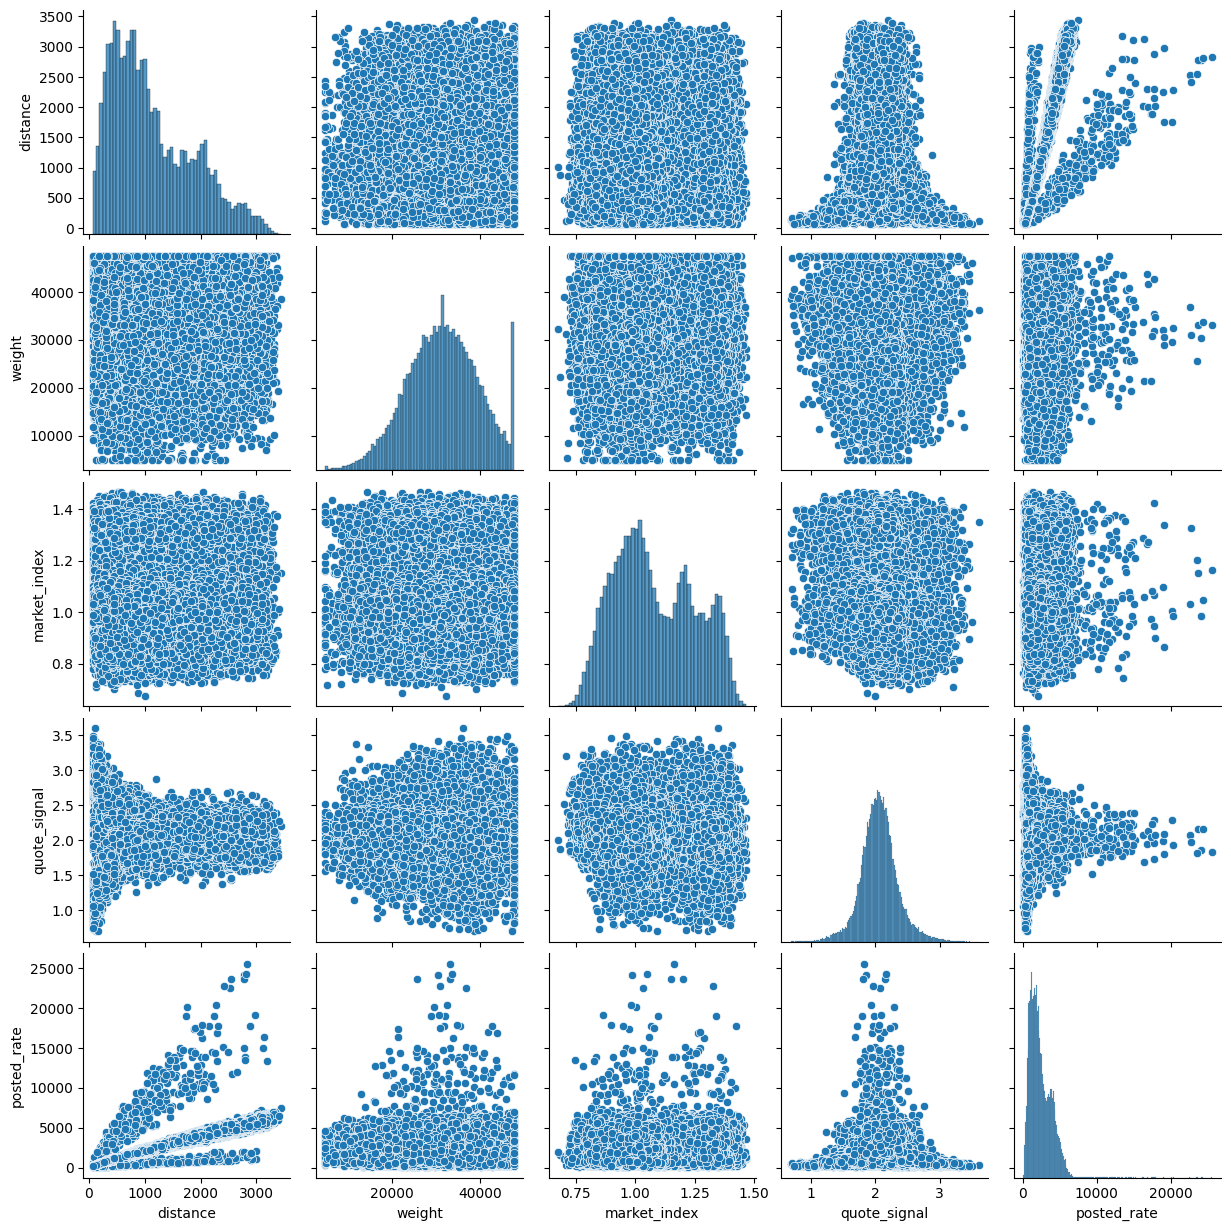

In [42]:
sns.pairplot(df[["distance",  "weight","market_index" , "quote_signal","posted_rate"]])

In [43]:
df.groupby("equipment")["posted_rate"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
equipment,,,,,,
Dry Van,27202,2271.548686,1953.035,1423.029914,57.22,25533.00
Flatbed,8753,2445.087223,2076.810,1505.053087,157.76,17893.17
Reefer,12045,2553.636939,2196.670,1589.670824,63.36,24140.21


# Preprocessing

In [44]:
# covert column "date" from object dtype to date dtype
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day

In [45]:
# Feature Engineering: Calculate trip direction (bearing angle) from geographical coordinates

def bearing_np(lat1, lon1, lat2, lon2):
    # convert to radain
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # calculate the difference between lon of 2 cities
    dlon = lon2 - lon1

    # get the x , y
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - (
        np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    )

    # calculate the angle
    initial_bearing = np.arctan2(x, y)

    # convert the radian to degree
    initial_bearing = np.degrees(initial_bearing)

    # make the angle between 0 and 360
    compass_bearing = (initial_bearing + 360) % 360

    return compass_bearing


df["bearing"] = bearing_np(
    df["pickup_lat"],
    df["pickup_lon"],
    df["delivery_lat"],
    df["delivery_lon"]
)

In [46]:
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,month,day_of_week,day_of_month,bearing
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,1,2,1,87.349653
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,1,2,1,68.043138
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,1,2,1,299.807683
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,1,2,1,251.678498
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,1,2,1,54.841795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,2025-10-31,0.98865,2.05626,3787.32,10,4,31,105.078805
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,2025-10-31,1.03034,1.51985,1171.93,10,4,31,267.652368
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,2025-10-31,1.00846,1.46954,713.36,10,4,31,291.314222
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,2025-10-31,1.00014,2.05132,3987.46,10,4,31,288.575743


In [47]:
#  do OneHotEncoding to equipment col

df = pd.get_dummies(df, columns=["equipment"], drop_first=True)


In [48]:
df

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,month,day_of_week,day_of_month,bearing,equipment_Flatbed,equipment_Reefer
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,2025-01-01,0.95684,2.39595,645.41,1,2,1,87.349653,False,False
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,2025-01-01,0.97623,2.43355,679.97,1,2,1,68.043138,False,True
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,2025-01-01,1.00971,1.84491,1802.54,1,2,1,299.807683,False,False
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,2025-01-01,0.94518,1.87712,1827.28,1,2,1,251.678498,False,False
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,2025-01-01,0.98480,2.56300,1380.28,1,2,1,54.841795,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,31786.0,2025-10-31,0.98865,2.05626,3787.32,10,4,31,105.078805,True,False
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,37465.0,2025-10-31,1.03034,1.51985,1171.93,10,4,31,267.652368,False,True
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,24528.0,2025-10-31,1.00846,1.46954,713.36,10,4,31,291.314222,True,False
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,37581.0,2025-10-31,1.00014,2.05132,3987.46,10,4,31,288.575743,True,False


In [49]:
# Time-based train/validation split

from sklearn.preprocessing import RobustScaler

num_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day_of_week",
    "day_of_month",
    "bearing",
]

df = df.sort_values("date").reset_index(drop=True)

# Hold out the most recent 2 months (Sep-Oct) as validation; train on
# everything before that. Adjust the offset if you want a longer/shorter
# validation window.
split_date = df["date"].max() - pd.DateOffset(months=2)
print("Split date:", split_date.date())

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X = df.drop(columns=["load_id", "date", "posted_rate", "pickup", "delivery"])
y = df["posted_rate"]

X_train, X_test = X[train_mask].copy(), X[test_mask].copy()
y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

print("Train size:", X_train.shape, "| Test size:", X_test.shape)

scaler = RobustScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


Split date: 2025-08-31
Train size: (38330, 14) | Test size: (9670, 14)


In [50]:
X_train

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,month,day_of_week,day_of_month,bearing,equipment_Flatbed,equipment_Reefer
0,0.376668,0.747581,0.387155,0.978005,-0.621179,-0.075930,-0.632727,1.037110,-1.333333,-0.25,-1.000000,-0.461166,False,False
1,-0.527842,0.131105,0.582831,-0.062940,-0.240053,1.450097,-0.647119,0.345946,-1.333333,-0.25,-1.000000,0.876152,False,False
2,0.573601,1.052470,0.863083,-0.153959,0.130938,-0.219725,-0.605368,-0.713621,-1.333333,-0.25,-1.000000,0.553926,False,False
3,0.573601,1.052470,-0.153749,0.514964,-0.246992,-0.520092,-0.766445,-0.454715,-1.333333,-0.25,-1.000000,0.275172,False,False
4,-0.906308,-1.892976,0.572941,-2.058791,-0.057525,-0.920944,-0.569158,-0.800570,-1.333333,-0.25,-1.000000,0.900257,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38325,0.595647,0.659212,-0.153749,0.514964,-0.430616,-1.903593,-0.985512,-0.085009,1.000000,0.50,0.933333,0.085005,False,False
38326,-0.899910,-0.516458,-0.459562,-0.731186,-0.559180,-0.144973,-0.672747,0.426560,1.000000,0.50,0.933333,0.762114,False,False
38327,-0.153749,0.552042,-0.137337,-0.299919,-0.094962,-0.190912,-0.983357,0.078857,1.000000,0.50,0.933333,0.499140,False,False
38328,0.536068,1.229805,0.529137,0.963354,-0.653777,-0.205953,-0.853487,-0.503599,1.000000,0.50,0.933333,0.477778,False,False


# Modeling

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import ExtraTreesRegressor




In [52]:
from sklearn.metrics import r2_score ,mean_absolute_error , mean_squared_error


def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    # prediction
    y_pred = model.predict(X_test)
    train_pred  = model.predict(X_train)
    train_r2 = round(r2_score(y_train, train_pred),4)
    r2 = round(r2_score(y_test, y_pred),4)
    mse = round(mean_squared_error(y_test, y_pred) ,4)
    mae = round(mean_absolute_error(y_test, y_pred),4)

    return train_r2,r2, mse, mae


In [53]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regressor": SVR(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LGBM": LGBMRegressor(random_state=42),
    "Adaboost": AdaBoostRegressor(random_state=42),
    "GBoost": GradientBoostingRegressor(random_state=42),
    "Stacking RF,LGBM": StackingRegressor(
        estimators=[
            ("RF", RandomForestRegressor(random_state=42)),
            ("lgbm", LGBMRegressor(random_state=42)),
        ],
        final_estimator=LGBMRegressor(random_state=42),
    ),
    "Voting RF,LGBM": VotingRegressor(
        estimators=[
            ("RF", RandomForestRegressor(random_state=42)),
            ("lgbm", LGBMRegressor(random_state=42)),
        ]
    ),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
}


results = []


for name, model in models.items():
    train_r2, test_r2, mse, mae = evaluate_model(model, X_train, X_test, y_train, y_test)
    results.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "MSE": mse,
        "MAE": mae,
    })


results_df = pd.DataFrame(results)
print(results_df)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1579
[LightGBM] [Info] Number of data points in the train set: 38330, number of used features: 14
[LightGBM] [Info] Start training from score 2369.480898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1579
[LightGBM] [Info] Number of data points in the train set: 38330, number of used features: 14
[LightGBM] [Info] Start training from score 2369.480898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1579
[LightGBM] [Info] Number of data points in the train set: 38330, number of used features: 14
[LightGBM] [Info] Start training from score 2369.480898
                       Model  Train R2  Test R2           MSE        MAE
0          Linear Regression    0.8402   0.8261  4.034331e+05   140.7779
1   Support Vector Regressor    0.6814   0.5328  1.084099e+06   666.4413
2    Decision Tree Regressor    1.0000   0.5739  9.887294e+05   224.7036
3              Random Forest    0.9759   0.8130  4.338994e+05   158.1339
4                    XGBoost    0.9549   0.7922  4.822428e+05   206.3340
5                       LGBM    0.8822   0.8265  4.025304e+05   131.8825
6                   Adaboost   -0.0126  -0.2981  3.012308e+06  1213.7862
7      

In [54]:
results_df.sort_values(by ="Test R2" , ascending= False)

,Model,Train R2,Test R2,MSE,MAE
7,GBoost,0.8602,0.8281,3.989801e+05,116.8711
5,LGBM,0.8822,0.8265,4.025304e+05,131.8825
0,Linear Regression,0.8402,0.8261,4.034331e+05,140.7779
9,"Voting RF,LGBM",0.9400,0.8249,4.063072e+05,133.1284
8,"Stacking RF,LGBM",0.8697,0.8244,4.074777e+05,135.2836
10,ExtraTrees,1.0000,0.8151,4.291608e+05,159.3931
3,Random Forest,0.9759,0.8130,4.338994e+05,158.1339
4,XGBoost,0.9549,0.7922,4.822428e+05,206.3340
2,Decision Tree Regressor,1.0000,0.5739,9.887294e+05,224.7036
1,Support Vector Regressor,0.6814,0.5328,1.084099e+06,666.4413


# HyperTuning for GBoost

In [55]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0],
}

gb_base = GradientBoostingRegressor(random_state=42)

# NOTE: with a time-based split, a plain KFold cv inside RandomizedSearchCV
# still shuffles across the training period. That's fine here since the
# held-out TEST set (last 2 months) is what we report on -- cv is only used
# to pick hyperparameters within the training period.
random_search = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist,
    n_iter=5,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)

gb = random_search.best_estimator_

y_pred_tuned = gb.predict(X_test)
y_train_pred = gb.predict(X_train)

print("Train R2 Score:", r2_score(y_train, y_train_pred))
print("Test R2 Score:", r2_score(y_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params: {'subsample': 0.7, 'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.2}
Train R2 Score: 0.8691991598061526
Test R2 Score: 0.821506111475636
MAE: 136.9379048598337
RMSE: 643.5832758120438


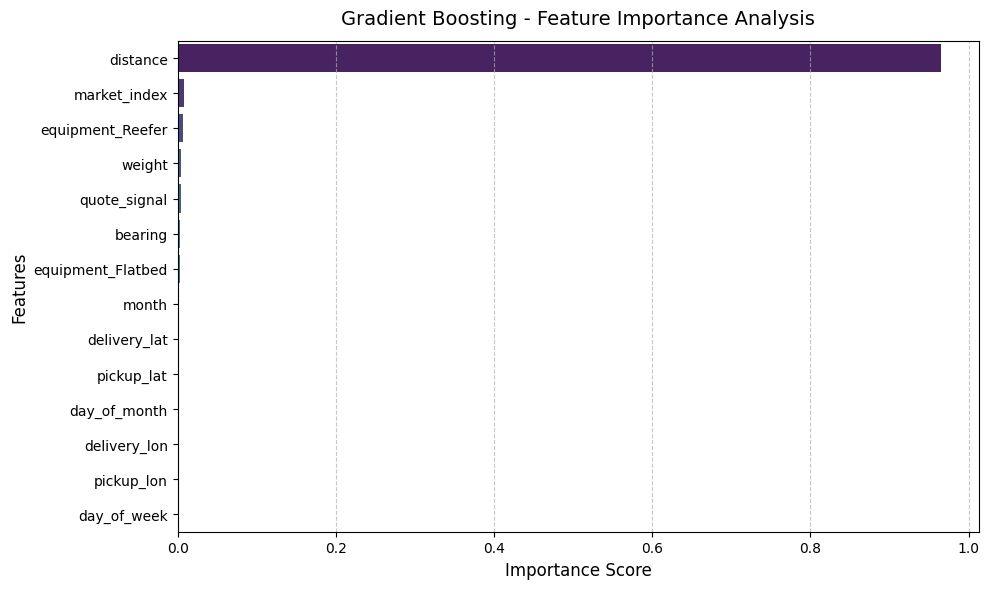

              Feature  Importance
0            distance    0.964731
1        market_index    0.007946
2    equipment_Reefer    0.006718
3              weight    0.004637
4        quote_signal    0.004471
5             bearing    0.003162
6   equipment_Flatbed    0.002471
7               month    0.001573
8        delivery_lat    0.001346
9          pickup_lat    0.000893
10       day_of_month    0.000700
11       delivery_lon    0.000676
12         pickup_lon    0.000582
13        day_of_week    0.000094


In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

importances = gb.feature_importances_
feature_names = X_train.columns


feature_imp_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)


plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_imp_df,
    palette="viridis",
    hue="Feature",
    legend=False,
)

plt.title(
    "Gradient Boosting - Feature Importance Analysis", fontsize=14, pad=12
)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print(feature_imp_df)

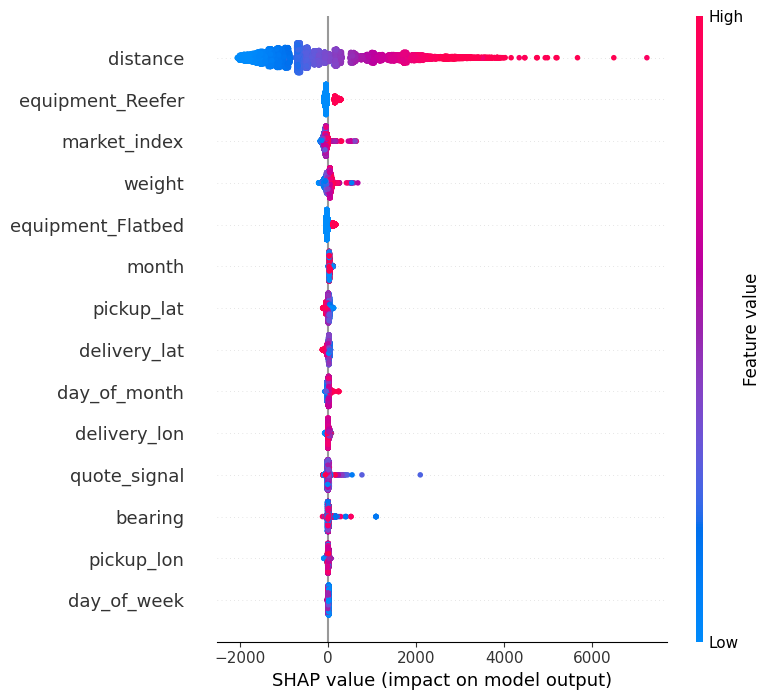

In [57]:
import shap


explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

In [58]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score


top_features = [
    "distance",
    "equipment_Reefer",
    "quote_signal",
    "weight",
    "market_index",
    "equipment_Flatbed",
]

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]


gb_selected = GradientBoostingRegressor(random_state=42)

gb_selected.fit(X_train_selected, y_train)


y_pred_selected = gb_selected.predict(X_test_selected)
y_tarin_predictrd = gb_selected.predict(X_train_selected)
print("Train R2 Score:", r2_score(y_train, y_tarin_predictrd))
print("Test R2 Score:", r2_score(y_test, y_pred_selected))
print("MAE:", mean_absolute_error(y_test, y_pred_selected))
print(
    "RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_selected))
)

Train R2 Score: 0.8584031582407129
Test R2 Score: 0.8242388125626807
MAE: 139.18517366515073
RMSE: 638.6377167155701


In [59]:
import numpy as np
import pandas as pd
import joblib

joblib.dump(gb, "gbr_final_model.pkl")
joblib.dump(scaler, "robust_scaler.pkl")
joblib.dump(list(X_train.columns), "train_columns.pkl")  # keep the order of columns


# save preprocessing
def bearing_np(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - (
        np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    )
    initial_bearing = np.arctan2(x, y)
    initial_bearing = np.degrees(initial_bearing)
    return (initial_bearing + 360) % 360


def preprocess_test_data(
    test_df,
    scaler_path="robust_scaler.pkl",
    columns_path="train_columns.pkl",
):
    df_proc = test_df.copy()
    # convert date to datetime type
    df_proc["date"] = pd.to_datetime(df_proc["date"])
    df_proc["month"] = df_proc["date"].dt.month
    df_proc["day_of_week"] = df_proc["date"].dt.dayofweek
    df_proc["day_of_month"] = df_proc["date"].dt.day

    # get the angle of direction
    df_proc["bearing"] = bearing_np(
        df_proc["pickup_lat"],
        df_proc["pickup_lon"],
        df_proc["delivery_lat"],
        df_proc["delivery_lon"],
    )

    # do oneHotEncoder for categorical column
    df_proc = pd.get_dummies(df_proc, columns=["equipment"], drop_first=True)


    cols_to_drop = [
        col
        for col in [
            "load_id",
            "date",
            "posted_rate",
            "pickup",
            "delivery",
        ]
        if col in df_proc.columns
    ]
    df_proc = df_proc.drop(columns=cols_to_drop)


    expected_columns = joblib.load(columns_path)
    for col in expected_columns:
        if col not in df_proc.columns:
            df_proc[col] = 0
    df_proc = df_proc[expected_columns]


    scaler = joblib.load(scaler_path)
    num_cols = [
        "pickup_lat",
        "pickup_lon",
        "delivery_lat",
        "delivery_lon",
        "distance",
        "weight",
        "market_index",
        "quote_signal",
        "month",
        "day_of_week",
        "day_of_month",
        "bearing",
    ]

    cols_to_scale = [c for c in num_cols if c in df_proc.columns]
    df_proc[cols_to_scale] = scaler.transform(df_proc[cols_to_scale])

    return df_proc

In [61]:
test_df = pd.read_csv("/content/validation.csv")
test_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  object 
 1   pickup        12000 non-null  object 
 2   delivery      12000 non-null  object 
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  object 
 9   weight        11835 non-null  float64
 10  date          12000 non-null  object 
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.2+ MB


In [62]:
test_df["weight"] = test_df["weight"].fillna(weight_median)

daily_market_median = df.groupby("date")["market_index"].median()
overall_market_median = df["market_index"].median()  # for dayes not exist on train
test_df["market_index"] = test_df["market_index"].fillna(
    test_df["date"].map(daily_market_median)
)
test_df["market_index"] = test_df["market_index"].fillna(overall_market_median)

In [63]:
test_df.isna().sum()

,0
load_id,0
pickup,0
delivery,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
distance,0
equipment,0
weight,0


In [64]:
X_new_test = preprocess_test_data(test_df)
loaded_model = joblib.load("gbr_final_model.pkl")
predictions = loaded_model.predict(X_new_test)

submission = pd.DataFrame(
    {"load_id": test_df["load_id"], "predicted_rate": predictions}
)

submission.to_csv("validation_predictions.csv", index=False)


In [65]:
sub = pd.read_csv("validation_predictions.csv")
sub


,load_id,predicted_rate
0,TE-000001,829.315219
1,TE-000002,4850.702243
2,TE-000003,5159.767400
3,TE-000004,3961.563017
4,TE-000005,1725.377411
...,...,...
11995,TE-011996,832.068680
11996,TE-011997,1647.244584
11997,TE-011998,969.645173
11998,TE-011999,3425.459871


# december-input-chart

In [91]:
december_df = pd.read_csv("/content/december-chart-inputs.csv")
december_df_copy = december_df.copy()
december_df.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


In [92]:
december_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pickup          31 non-null     object 
 1   delivery        31 non-null     object 
 2   distance        31 non-null     int64  
 3   equipment       31 non-null     object 
 4   weight          31 non-null     int64  
 5   date            31 non-null     object 
 6   predicted_rate  0 non-null      float64
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ KB


In [69]:
X_train.columns

Index(['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance',
       'weight', 'market_index', 'quote_signal', 'month', 'day_of_week',
       'day_of_month', 'bearing', 'equipment_Flatbed', 'equipment_Reefer'],
      dtype='object')

In [72]:
df [ df["pickup"] == "Lexington"].head(1)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,month,day_of_week,day_of_month,bearing,equipment_Flatbed,equipment_Reefer
7,TR-000093,Lexington,Baton Rouge,36.99152,-84.99876,30.50134,-92.65374,749.7,23380.0,2025-01-01,0.95581,2.04041,1537.18,1,2,1,226.632567,False,False


In [74]:
df [ df["delivery"] == "Fort Wayne"].head(1)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,month,day_of_week,day_of_month,bearing,equipment_Flatbed,equipment_Reefer
14,TR-000107,San Antonio,Fort Wayne,29.50969,-98.40059,41.31561,-85.36206,1266.0,20678.0,2025-01-01,0.98745,1.99624,2498.9,1,2,1,38.355228,True,False


In [93]:
december_df['pickup_lat'] = 36.99152
december_df['pickup_lon'] = -84.99876
december_df["delivery_lat"] = 41.31561
december_df["delivery_lon"] = -85.36206

daily_market_val = test_df.groupby("date")["market_index"].median()
daily_quote_val = test_df.groupby("date")["quote_signal"].median()

overall_quote_median = df["quote_signal"].median()

december_df["market_index"] = december_df["date"].map(daily_market_val)
december_df["quote_signal"] = december_df["date"].map(daily_quote_val)

# fallback, just in case a date isn't covered by validation.csv
december_df["market_index"] = december_df["market_index"].fillna(overall_market_median)
december_df["quote_signal"] = december_df["quote_signal"].fillna(overall_quote_median)


In [94]:
X_train.columns

Index(['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance',
       'weight', 'market_index', 'quote_signal', 'month', 'day_of_week',
       'day_of_month', 'bearing', 'equipment_Flatbed', 'equipment_Reefer'],
      dtype='object')

In [95]:
december_df.columns

Index(['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date',
       'predicted_rate', 'pickup_lat', 'pickup_lon', 'delivery_lat',
       'delivery_lon', 'market_index', 'quote_signal'],
      dtype='object')

In [96]:
X_new_test = preprocess_test_data(december_df)
loaded_model = joblib.load("gbr_final_model.pkl")
predictions = loaded_model.predict(X_new_test)



In [97]:
predictions

array([788.09567205, 779.98742771, 781.06543473, 787.11585147,
       764.54184384, 766.25161374, 773.31855812, 774.21424443,
       783.08836185, 783.07123118, 802.89473385, 787.6741969 ,
       789.84033511, 789.78563365, 803.357197  , 803.08267665,
       821.00451021, 837.2950869 , 798.59860333, 793.26283097,
       793.20812951, 800.65185629, 809.93905665, 822.40506207,
       832.85026103, 799.9991552 , 798.24682376, 797.58119405,
       814.69918473, 829.77793212, 842.48790056])

In [100]:
december_df_copy["predicted_rate"] = predictions
december_df_copy.to_csv("december-chart-inputs.csv", index=False)

In [101]:
# 5) Run score.py: validates both files and draws the December chart
!python /content/score.py --predictions validation_predictions.csv --december-predictions /content/december-chart-inputs.csv


Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


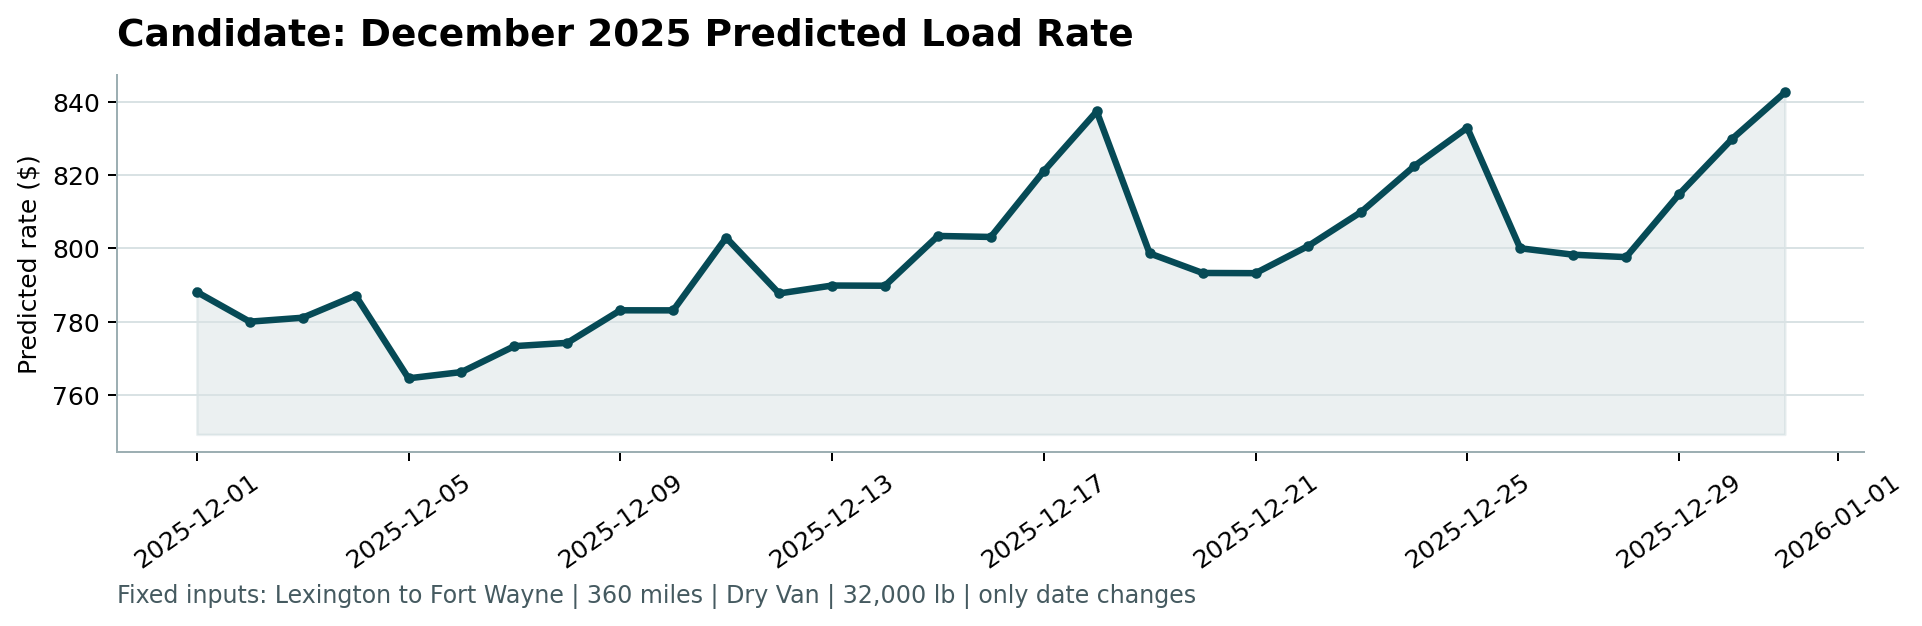

In [102]:
from IPython.display import Image, display

display(Image("/content/scorer_results/candidate_december.png"))